# Large scale Gauss-Newton

Let's try it on a ViT model with layers using the layer formulation. 

## Imports and data

In [1]:
from timeit import timeit

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from typing import Sequence, List, Tuple, Callable
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools
from jax.scipy.linalg import block_diag
import optax
from datasets import load_dataset
from functools import partial


from jax import random
# Seeding for random operations
main_rng = random.PRNGKey(42)

# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


In [2]:
def get_datasets():
    """Load MNIST train and test datasets into memory."""
    # Load the MNIST dataset
    dataset = load_dataset('mnist')

    # Convert datasets to numpy arrays
    train_ds = {
        'image': jnp.array(dataset['train']['image']),
        'label': jnp.array(dataset['train']['label'])
    }
    test_ds = {
        'image': jnp.array(dataset['test']['image']),
        'label': jnp.array(dataset['test']['label'])
    }

    # Normalize the images
    train_ds['image'] = train_ds['image'].astype(jnp.float32) / 255.0
    test_ds['image'] = test_ds['image'].astype(jnp.float32) / 255.0

    # Reshape to mimic 3D
    train_ds['image'] = jnp.expand_dims(train_ds['image'], axis=-1)
    test_ds['image'] = jnp.expand_dims(test_ds['image'], axis=-1)


    return train_ds, test_ds

In [3]:
# Get datasets as dict of JAX arrays.
train_ds, test_ds = get_datasets()

In [4]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - torch.Tensor representing the image of shape [B, H, W, C]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, H, W, C = x.shape
    x = x.reshape(B, H//patch_size, patch_size, W//patch_size, patch_size, C)
    x = x.transpose(0, 1, 3, 2, 4, 5)    # [B, H', W', p_H, p_W, C]
    x = x.reshape(B, -1, *x.shape[3:])   # [B, H'*W', p_H, p_W, C]
    if flatten_channels:
        x = x.reshape(B, x.shape[1], -1) # [B, H'*W', p_H*p_W*C]
    return x

In [5]:
class AttentionBlock(nn.Module):
    embed_dim : int   # Dimensionality of input and attention feature vectors
    hidden_dim : int  # Dimensionality of hidden layer in feed-forward network
    num_heads : int   # Number of heads to use in the Multi-Head Attention block
    # dropout_prob : float = 0.0  # Amount of dropout to apply in the feed-forward network

    def setup(self):
        self.attn = nn.MultiHeadDotProductAttention(num_heads=self.num_heads)
        self.linear = [
            nn.Dense(self.hidden_dim),
            nn.gelu,
            # nn.Dropout(self.dropout_prob),
            nn.Dense(self.embed_dim)
        ]
        self.layer_norm_1 = nn.LayerNorm()
        self.layer_norm_2 = nn.LayerNorm()
        # self.dropout = nn.Dropout(self.dropout_prob)

    def __call__(self, x):
        inp_x = self.layer_norm_1(x)
        attn_out = self.attn(inputs_q=inp_x, inputs_kv=inp_x)
        # x = x + self.dropout(attn_out, deterministic=not train)
        x = x + attn_out

        linear_out = self.layer_norm_2(x)
        for l in self.linear:
            linear_out = l(linear_out)
        # x = x + self.dropout(linear_out, deterministic=not train)
        x = x + linear_out
        
        return x

In [6]:
class Preprocessor(nn.Module):
    embed_dim: int
    patch_size: int
    num_patches: int

    def setup(self):
        self.input_layer = nn.Dense(self.embed_dim)
        self.pos_embedding = self.param('pos_embedding',
                                        nn.initializers.normal(stddev=1.0),
                                        (1, 1 + self.num_patches, self.embed_dim))
        self.cls_token = self.param('cls_token',
                                    nn.initializers.normal(stddev=1.0),
                                    (1, 1, self.embed_dim))

    def __call__(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, axis=0)
        x = jnp.concatenate([cls_token, x], axis=1)
        x = x + self.pos_embedding[:, :T + 1]
        return x


class ClassificationHead(nn.Module):
    embed_dim: int
    num_classes: int

    def setup(self):
        self.mlp_head = nn.Sequential([
            nn.LayerNorm(),
            nn.Dense(self.num_classes)
        ])

    def __call__(self, x):
        # Perform classification prediction
        cls = x[:, 0]
        out = self.mlp_head(cls)
        return out


class VisionTransformer(nn.Module):
    embed_dim: int     # Dimensionality of input and attention feature vectors
    hidden_dim: int    # Dimensionality of hidden layer in feed-forward network
    num_heads: int     # Number of heads to use in the Multi-Head Attention block
    num_channels: int  # Number of channels of the input (3 for RGB)
    num_layers: int    # Number of layers to use in the Transformer
    num_classes: int   # Number of classes to predict
    patch_size: int    # Number of pixels that the patches have per dimension
    num_patches: int   # Maximum number of patches an image can have
    # dropout_prob: float = 0.0  # Amount of dropout to apply in the feed-forward network

    def setup(self):
        # All layers
        self.layers = [Preprocessor(self.embed_dim, self.patch_size, self.num_patches)] + [
            AttentionBlock(self.embed_dim,
                                           self.hidden_dim,
                                           self.num_heads,
                                           ) for _ in range(self.num_layers)
        ] + [ClassificationHead(self.embed_dim, self.num_classes)]


    def __call__(self, x, layer_out: bool = False) -> Tuple[jax.Array, List[jax.Array]]:
        intermediate_inputs = [x]
        y = x
        
        # Apply Transformer
        for i, layer in enumerate(self.layers):
            y = layer(y)
            y = self.perturb(f'layer_{i+1}', y)
            intermediate_inputs.append(y)
            
        # The final `y` is the final output. The inputs list is one item too long.
        final_output = intermediate_inputs.pop()

        if not layer_out:
            return final_output
            
        return final_output, intermediate_inputs


    def get_jacobian_calculators(self) -> List[Callable]:
        """
        Creates a list of functions that compute the Jacobian of each layer's
        output with respect to its parameters.

        This method is called via `model.apply(..., method=...)`, which ensures
        that `self.layers` is available.

        Adapted for VisualTransformer, noting that the middle layers are the same functions as they're all 
        just self-attention. 
        """
        jacobian_fns = []

        def layer_apply_fn(layer_instance: nn.Module, params: dict, layer_input: jax.Array) -> jax.Array:
            """A wrapper to call a single layer's apply method."""
            return layer_instance.apply({'params': params}, layer_input)

        # Compute Jacobian for the preprocessor layer
        # jacobian_fns.append(jax.jacrev(partial(layer_apply_fn, self.layers[0]), argnums=0))
        jacobian_fns.append(jax.jacfwd(partial(layer_apply_fn, self.layers[0]), argnums=0))
    
        # Compute Jacobian for one representative attention block
        attention_block = self.layers[1]  # Assuming all middle layers are identical
        # attention_jac_fn = jax.jacrev(partial(layer_apply_fn, attention_block), argnums=0)
        attention_jac_fn = jax.jacfwd(partial(layer_apply_fn, attention_block), argnums=0)
    
        # Reuse the Jacobian function for all identical attention blocks
        jacobian_fns.extend([attention_jac_fn] * self.num_layers)
    
        # Compute Jacobian for the classification head
        # jacobian_fns.append(jax.jacrev(partial(layer_apply_fn, self.layers[-1]), argnums=0))
        jacobian_fns.append(jax.jacfwd(partial(layer_apply_fn, self.layers[-1]), argnums=0))

        return jacobian_fns



In [35]:
lamb = 0.1
def train_model_precond(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64, use_initial: bool=False):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )
    
    # Grab each layer's things
    layer_jacobian = model.apply(
        {'params': state.params}, method=model.get_jacobian_calculators
    )
    # treescope.display(layer_jacobian)

    @jax.jit # This takes list, and makes them static; can be jitted easily
    def get_correction(k_list, global_adjoints, grad, H_inv, lamb: float=1e-1):
        """
        Assumes grad is a vector
        """
        p_list = [k.shape[1] for k in k_list]
        p_list.insert(0, 0)
        indices = list(itertools.accumulate(p_list))
        j_shape = global_adjoints[0].shape[0]

        # Save 
        j_i = []
        aux_var = jnp.zeros(j_shape)
        # aux_var = jnp.zeros(j_shape, dtype=jnp.float32)
        
        sum_mat = H_inv
        for i in range(len(k_list)):
            # Use the SMW formulation; first do Jv
            j_i.append(global_adjoints[i] @ k_list[i])
            sum_mat += j_i[i] @ j_i[i].T / lamb
            aux_var += j_i[i] @ grad[indices[i]:indices[i+1]]

            # sum_mat += (j_i[i].astype(jnp.float32) @ j_i[i].T.astype(jnp.float32)) / lamb
            # aux_var += j_i[i].astype(jnp.float32) @ grad[indices[i]:indices[i+1]].astype(jnp.float32)
            
        aux_var = jnp.linalg.solve(sum_mat, aux_var)
        # aux_var = jnp.linalg.solve(sum_mat.astype(jnp.float32), aux_var.astype(jnp.float32)).astype(jnp.float64)
        
        # Finally do J^T v and scale
        # out = jnp.concat([k_list[i].T @ (global_adjoints[i].T @ aux_var) for i in range(len(k_list))]) / (lamb ** 2)
        out = jnp.concat([j_i[i].T @ aux_var for i in range(len(k_list))]) / (lamb ** 2)

        # Don't forget the 1/lambda I
        return -out + grad / lamb

    @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 10)
        def loss_fn(params):
            logits, layer_vals  = state.apply_fn(params, batch_X, layer_out=True)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, (logits, layer_vals)

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, (logits, layer_vals)), grads = grad_fn({'params': state.params})

        # Get the corrections 
        flattened_grads, back = jax.flatten_util.ravel_pytree(grads)

        # Generalized Gauss-Newton is J^THJ
        # First calculate H; this is a diagonal 
        probs = jax.nn.softmax(logits, axis=-1).flatten()
        diag_probs = jnp.diag(probs)
        diag_probs_inv = jnp.diag(1 / probs)  # Inverse of the diagonal matrix
        outer_probs = jnp.outer(probs, probs)
        denominator = 1 - jnp.dot(probs, jnp.dot(diag_probs_inv, probs))
        numerator = jnp.dot(diag_probs_inv, outer_probs) @ diag_probs_inv
        H_inv = diag_probs_inv + numerator / denominator

        # Calculate the Jacobian wrt adjoints
        if use_initial:
            jacobian = jax.jacobian(
                lambda params, perturbations, batch_X: model.apply(
                    {'params': params, 'perturbations': perturbations}, batch_X
                ),
                argnums=1
            )(
                params['params'], params['perturbations'], batch_X
                # params['params'].astype(jnp.float32), 
                # params['perturbations'].astype(jnp.float32), 
                # batch_X.astype(jnp.float32)
            )
        else:
            state_params_float32 = jax.tree.map(lambda x: x.astype(jnp.float32), state.params)
            state_perturbations_float32 = jax.tree.map(lambda x: x.astype(jnp.float32), params['perturbations'])
            jacobian = jax.jacobian(
                lambda params, perturbations, batch_X: model.apply(
                    {'params': params, 'perturbations': perturbations}, batch_X
                ),
                argnums=1
            )(
                state.params, params['perturbations'], batch_X
                # state_params_float32, 
                # state_perturbations_float32, 
                # batch_X.astype(jnp.float32)

            )

        flattened, _ = jax.tree.flatten(
            jacobian
        )
        global_adjoints = [leaf.reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]

        # Now do the layer calculations
        layers = []
        for i, (jac_fn, layer_input) in enumerate(zip(layer_jacobian, layer_vals)):
            if use_initial:
                layer_params = params['params'][f'layers_{i}']
            else:
                layer_params = state.params[f'layers_{i}']
                
            jacobian_pytree = jac_fn(layer_params, layer_input)            
            layer_weights = jax.tree.flatten(jacobian_pytree)[0]
            layer_weights = [weights.reshape((global_adjoints[i].shape[1], -1)) for weights in layer_weights]
            layer_weights = jnp.concatenate(layer_weights, axis=-1)
            layers.append(layer_weights)

        corrected = get_correction(layers, global_adjoints, flattened_grads, H_inv, 0.1)
        grads = back(corrected)

        state = state.apply_gradients(grads=grads['params'])
        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            
    return state, epoch_loss, epoch_accuracy

num_epochs = 1

# Train the model
# trained_state_precond_init, precond_losses_init, precond_accuracy_init = train_model_precond(
#     train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=True
# )

# jax.config.update("jax_enable_x64", True)
# jax.config.update('jax_default_matmul_precision', 'highest')
# trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
#     train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=False
# )

print('Done')

Done


4138
Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

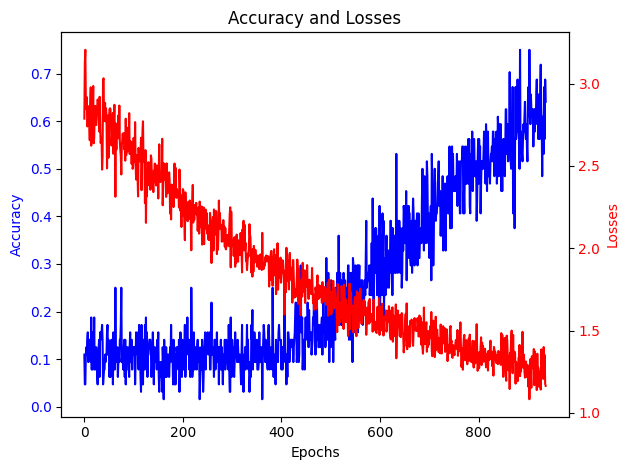

In [44]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'high')

key = jax.random.PRNGKey(0)
model =  VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )

# Hmm, input must match batch size? 
bsz = 64
params = model.init(key, jnp.ones((bsz, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 

trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=False
)

# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_init, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_naive_init, color='g', alpha=.5,label='Precond Accuracy')

# ax1.plot(sgd_accuracy, color='g', label='SGD Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses, color='r', label='SGD Losses')
# ax2.plot(precond_losses_init, color='r', label='SGD Losses')
# ax2.plot(precond_losses_naive_init, color='g', alpha=.2, label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()

4138
Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

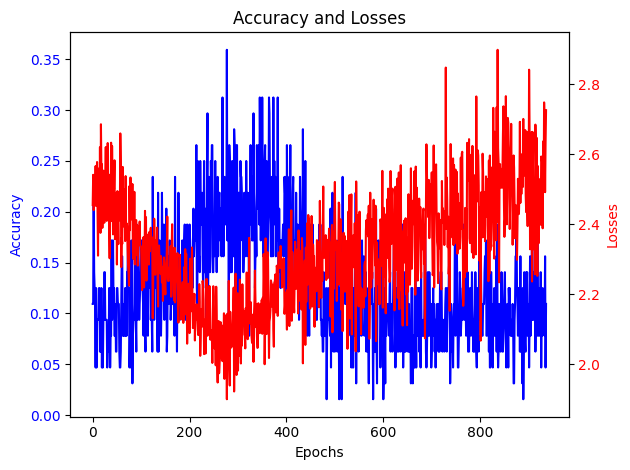

In [21]:
jax.config.update("jax_enable_x64", False)
jax.config.update("jax_default_matmul_precision", 'default')

num_epochs = 1

key = jax.random.PRNGKey(0)

model = VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )
bsz = 64
params = model.init(key, jnp.ones((bsz, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))


train_ds, test_ds = get_datasets()
trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=False
)

# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_init, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_naive_init, color='g', alpha=.5,label='Precond Accuracy')

# ax1.plot(sgd_accuracy, color='g', label='SGD Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses, color='r', label='SGD Losses')
# ax2.plot(precond_losses_init, color='r', label='SGD Losses')
# ax2.plot(precond_losses_naive_init, color='g', alpha=.2, label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()

In [22]:
def train_model_naive_precond(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64, use_initial: bool=False):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 10)
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})

        if use_initial:
            jacobian = jax.jacobian(model.apply, argnums=0)(params, batch_X)['params']
        else:
            jacobian = jax.jacobian(model.apply, argnums=0)(
                {'params': state.params}, batch_X
            )['params']
        flattened, _ = jax.tree.flatten(
            jacobian
        )

        reshaped_leaves = [leaf.reshape(
            bsz * 10, 1, -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        J = aggregated_array.reshape((bsz * 10, -1))
        # treescope.display(J)
        
        # Generalized Gauss-Newton is J^THJ
        probs = jax.nn.softmax(logits, axis=-1).flatten()
        diag_probs = jnp.diag(probs)
        outer_probs = jnp.outer(probs, probs)
        H = diag_probs - outer_probs

        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(J.T @ H @ J + 0.1 *  jnp.eye(J.shape[1]), flattened)
        grads = back(altered)

        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            
    return state, epoch_loss, epoch_accuracy



4138
Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

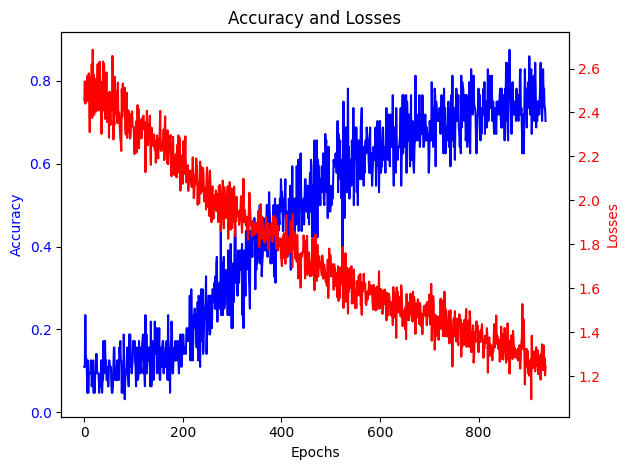

In [23]:
jax.config.update("jax_enable_x64", False)
jax.config.update("jax_default_matmul_precision", 'default')


num_epochs = 1

key = jax.random.PRNGKey(0)

model = VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )
bsz = 64
params = model.init(key, jnp.ones((bsz, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
jax.config.update("jax_enable_x64", False)
jax.config.update("jax_default_matmul_precision", 'default')
train_ds, test_ds = get_datasets()

trained_state_precond_naive, precond_losses_naive, precond_accuracy_naive = train_model_naive_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz
)

# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy_naive, color='b', label='SGD Accuracy')
# ax1.plot(sgd_accuracy, color='b', label='SGD Accuracy')

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses_naive, color='r', label='SGD Losses')
# ax2.plot(sgd_losses, color='g', label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()


4138
Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

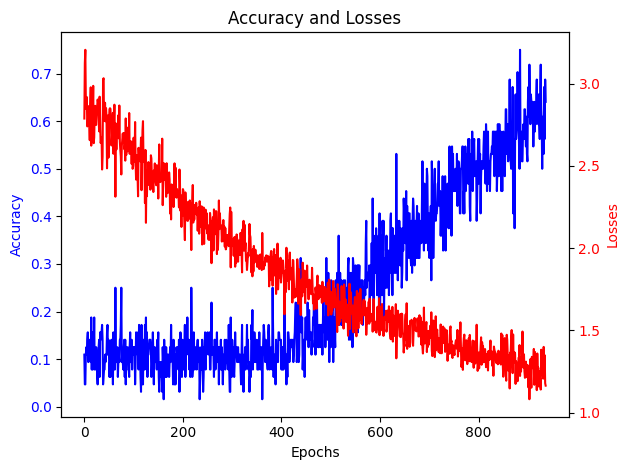

In [24]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


num_epochs = 1

key = jax.random.PRNGKey(0)

model = VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )
bsz = 64
params = model.init(key, jnp.ones((bsz, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
jax.config.update("jax_enable_x64", False)
jax.config.update("jax_default_matmul_precision", 'default')
train_ds, test_ds = get_datasets()

trained_state_precond_naive, precond_losses_naive, precond_accuracy_naive = train_model_naive_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz
)

# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy_naive, color='b', label='SGD Accuracy')
# ax1.plot(sgd_accuracy, color='b', label='SGD Accuracy')

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses_naive, color='r', label='SGD Losses')
# ax2.plot(sgd_losses, color='g', label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()


Notes: 
- Lower precision on traditional GNG matrix (aka no layer transform) works.
- However, it is still demonstrably different from "full precision" GNG
- jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'high') failed; but with x64 it works... I think it has to do with the many matrix multiplications?
- Very hard to individually parse the framework. 